In [1]:
import os
from pathlib import Path
import jwst
print(jwst.__version__)
from jwst import datamodels
from jwst.datamodels import dqflags

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from scipy.optimize import curve_fit
from scipy.stats import norm, poisson
from scipy.special import gamma

from pathlib import Path

# import natural units:
import natural_units as nu
# Plotting tools:
from pipeline1_plotting_tools import download_files, plot_jump, plot_jumps, plot_ramp, plot_ramps, show_image, side_by_side


1.15.1


In [4]:
unmasked_path = Path('./results/unmasked')
dn_min = -200
dn_max = 400
dn_range = range(dn_min, dn_max)

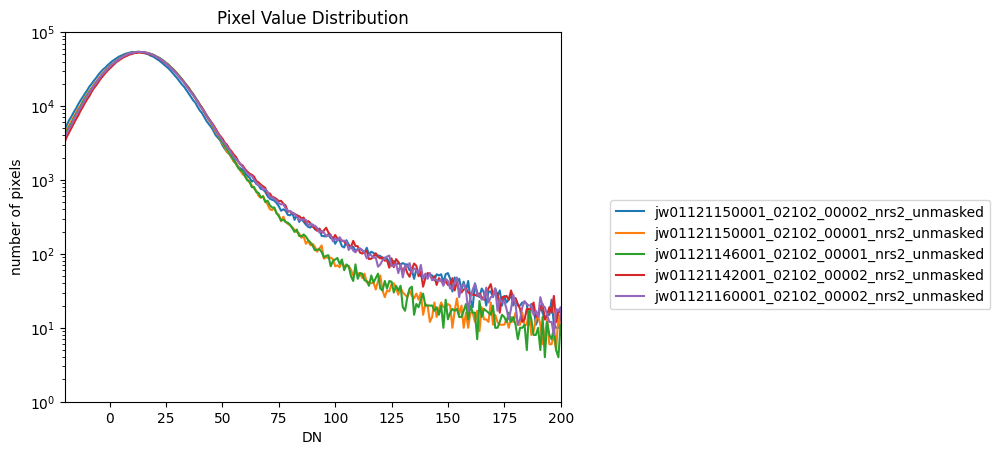

In [35]:
plt.figure()
i = 0
for item in unmasked_path.iterdir():
    if  0 <= i < 5:
        pvd  = np.loadtxt(item) # pvd stands for pixel value distribution
        peak = np.argmax(pvd[:,1])+dn_min
        peakshift = 13 - peak
        plt.semilogy(pvd[:,0]+peakshift,pvd[:,1], label = item.stem)
        #print(item.name + 'peak at: {}'.format(np.argmax(pvd[:,1])+dn_min))
    i += 1

plt.xlim(-20,200)
plt.ylim(1,1e5)
plt.legend(loc = (1.1,0.25))
plt.xlabel('DN')
plt.ylabel('number of pixels')
plt.title('Pixel Value Distribution')
plt.show()